In [ ]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

In [2]:
# Path to your saved pickle file
pickle_path = "../../data/Georgios/pcy_pass1/pcy_pass1_results.pkl"

# 1. Check if the file exists
if not os.path.exists(pickle_path):
    raise FileNotFoundError(f"Pickle file not found at: {pickle_path}")

print(f"Pickle found at: {pickle_path}")

# 2. Load pickle
with open(pickle_path, "rb") as f:
    data = pickle.load(f)

print("Pickle loaded successfully!")

# 3. Extract variables
baskets = data["baskets"]
num_unique_items = data["num_unique_items"]
bucket_options = data["bucket_options"]
support_percentages = data["support_percentages"]
results = data["results"]

# 4. Print confirmation
print("Loaded keys:", data.keys())
print("Number of baskets:", len(baskets))
print("Unique items:", num_unique_items)
print("Bucket options:", bucket_options)
print("Support percentages:", support_percentages)

print("\nMatrix results shape:", results.shape)
print("Everything is loaded and ready for the final PCY run.")


Pickle found at: ../../data/Georgios/pcy_pass1/pcy_pass1_results.pkl
Pickle loaded successfully!
Loaded keys: dict_keys(['baskets', 'num_unique_items', 'bucket_options', 'support_percentages', 'results'])
Number of baskets: 3214874
Unique items: 49677
Bucket options: [49677, 74515, 99354, 149031]
Support percentages: [0.001, 0.002, 0.005, 0.01]

Matrix results shape: (4, 4)
Everything is loaded and ready for the final PCY run.


In [3]:
# final parameters
num_buckets = 75000                      # chosen from the experiment
support_percentage = 0.005               # 0.5%
support_threshold = int(len(baskets) * support_percentage)

print("Final PCY configuration:")
print(" - Buckets:", num_buckets)
print(" - Support threshold:", support_threshold)

# final pass 1
print("\nRunning PCY Final Pass 1...")

# Count single items
from collections import Counter
item_counts = Counter()
for basket in baskets:
    item_counts.update(basket)

# Bucket counts
bucket_counts = np.zeros(num_buckets, dtype=int)

# Hash pairs into buckets
for basket in baskets:
    b = sorted(basket)
    for i in range(len(b)):
        for j in range(i+1, len(b)):
            a, c = b[i], b[j]
            h = (a * 13 + c * 7) % num_buckets
            bucket_counts[h] += 1

print("Pass 1 complete!")

# Bitmaps
bitmap = (bucket_counts >= support_threshold)
print("Bitmap created.")
print("Number of frequent buckets:", bitmap.sum())

Final PCY configuration:
 - Buckets: 75000
 - Support threshold: 16074

Running PCY Final Pass 1...
Pass 1 complete!
Bitmap created.
Number of frequent buckets: 144


In [ ]:
print("Running PCY Final Pass 2...")

# ---- Step 1: filter frequent single items ----
frequent_items = {item for item, count in item_counts.items()
                    if count >= support_threshold}

print("Frequent single items:", len(frequent_items))

# ---- Step 2: count only promising pairs ----
pair_counts = defaultdict(int)

for basket in baskets:
    # keep only frequent items
    b = sorted([x for x in basket if x in frequent_items])
    
    # skip tiny baskets
    if len(b) < 2:
        continue
    
    # check pairs
    for i in range(len(b)):
        for j in range(i+1, len(b)):
            a, c = b[i], b[j]
            
            # compute hash bucket for this pair
            h = (a * 13 + c * 7) % num_buckets
            
            # only count pairs in frequent buckets
            if bitmap[h]:
                pair_counts[(a, c)] += 1

print("Pass 2 pair counting complete!")
print("Candidate pairs counted:", len(pair_counts))


Running PCY Final Pass 2...
Frequent single items: 252
Pass 2 pair counting complete!
Candidate pairs counted: 211


In [5]:
# Extract FINAL frequent pairs
frequent_pairs = {pair: cnt for pair, cnt in pair_counts.items()
                    if cnt >= support_threshold}

print("True frequent pairs found:", len(frequent_pairs))


True frequent pairs found: 74


<h3><span style="color:green; font-weight:bold; background-color: #f0f0f0; padding: 6px; border-radius: 4px;">
Converting Frequent Pairs to Product Names and Extracting Top Results </span></h3>


Τhe frequent item pairs obtained from the PCY algorithm are mapped from product IDs to readable product names.</br> 
The pairs are then sorted by frequency, and the top 10 most common associations are displayed for analysis.

In [ ]:
# Load the products file
products_df = pd.read_csv("../../data/products.csv")

# Create mapping product_id -> product_name
id_to_name = dict(zip(products_df["product_id"], products_df["product_name"]))

# Convert pair ids to readable names
named_pairs = {
    (id_to_name[a], id_to_name[b]): cnt
    for (a, b), cnt in frequent_pairs.items()
    if a in id_to_name and b in id_to_name
}

print("Converted pairs:", len(named_pairs))

# Sort by frequency (descending)
top_10_pairs = sorted(named_pairs.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 Frequent Product Pairs:")
for (prodA, prodB), cnt in top_10_pairs:
    print(f"{prodA}  &  {prodB}  →  {cnt} times")

Converted pairs: 74

Top 10 Frequent Product Pairs:
Bag of Organic Bananas  &  Organic Hass Avocado  →  62341 times
Bag of Organic Bananas  &  Organic Strawberries  →  61628 times
Organic Strawberries  &  Banana  →  56156 times
Banana  &  Organic Avocado  →  53395 times
Organic Baby Spinach  &  Banana  →  51395 times
Bag of Organic Bananas  &  Organic Baby Spinach  →  50372 times
Strawberries  &  Banana  →  41232 times
Banana  &  Large Lemon  →  40880 times
Organic Strawberries  &  Organic Hass Avocado  →  40794 times
Bag of Organic Bananas  &  Organic Raspberries  →  40503 times


<h3><span style="color:green; font-weight:bold; background-color: #f0f0f0; padding: 6px; border-radius: 4px;">
Association Rule Metrics</span></h3>

For each frequent product pair from PCY, calculate the main association rule metrics:

- support (how often the pair appears)
- confidence (how reliable the rule A→B or B→A is)
- lift (how strong the association is compared to chance)

The rules are sorted by lift, highlighting the strongest associations.

In [13]:
rules = []

N = len(baskets)

for (a, b), pair_cnt in frequent_pairs.items():

    # Support of pair
    support_ab = pair_cnt / N

    # Support of single items
    support_a = item_counts[a] / N
    support_b = item_counts[b] / N

    # Confidence A → B and B → A
    confidence_a_b = support_ab / support_a
    confidence_b_a = support_ab / support_b

    # Lift
    lift_ab = support_ab / (support_a * support_b)

    rules.append({
        "A": id_to_name[a],
        "B": id_to_name[b],
        "support": support_ab,
        "confidence_A_to_B": confidence_a_b,
        "confidence_B_to_A": confidence_b_a,
        "lift": lift_ab
    })

# Sort by lift
rules_sorted = sorted(rules, key=lambda x: x["lift"], reverse=True)

# Show top 10 rules
df_rules = pd.DataFrame(rules_sorted[:20])
df_rules


,A,B,support,confidence_A_to_B,confidence_B_to_A,lift
0,Limes,Organic Cilantro,0.005464,0.124905,0.252647,5.775753
1,Organic Yellow Onion,Organic Garlic,0.006866,0.194603,0.201069,5.698983
2,Limes,Large Lemon,0.008524,0.194863,0.179507,4.103710
3,Organic Lemon,Organic Hass Avocado,0.006609,0.242131,0.099474,3.644560
4,Organic Cucumber,Organic Hass Avocado,0.005430,0.217136,0.081729,3.268339
5,Organic Strawberries,Organic Raspberries,0.010533,0.127938,0.247072,3.000973
6,Large Lemon,Organic Avocado,0.007595,0.159947,0.138093,2.908174
7,Organic Strawberries,Organic Blueberries,0.007389,0.089753,0.237418,2.883704
8,Limes,Organic Avocado,0.006846,0.156513,0.124480,2.845746
9,Organic Raspberries,Organic Hass Avocado,0.008023,0.188192,0.120763,2.832669


<h3> <span style="color:green; font-weight:bold; background-color: #f0f0f0; padding: 6px; border-radius: 4px;"> 
Visualization of Frequent vs Strong Associations </span>
</h3>


This section compares two different perspectives of the product pairs identified by PCY.  
On the left, the plot shows the pairs that appear most frequently in the dataset 
(purely based on co-occurrence counts).  
On the right, the plot highlights the strongest associations based on lift, which 
indicates how strongly two products are related relative to random chance.  
This side-by-side visualization helps distinguish common product combinations 
from statistically significant relationships.

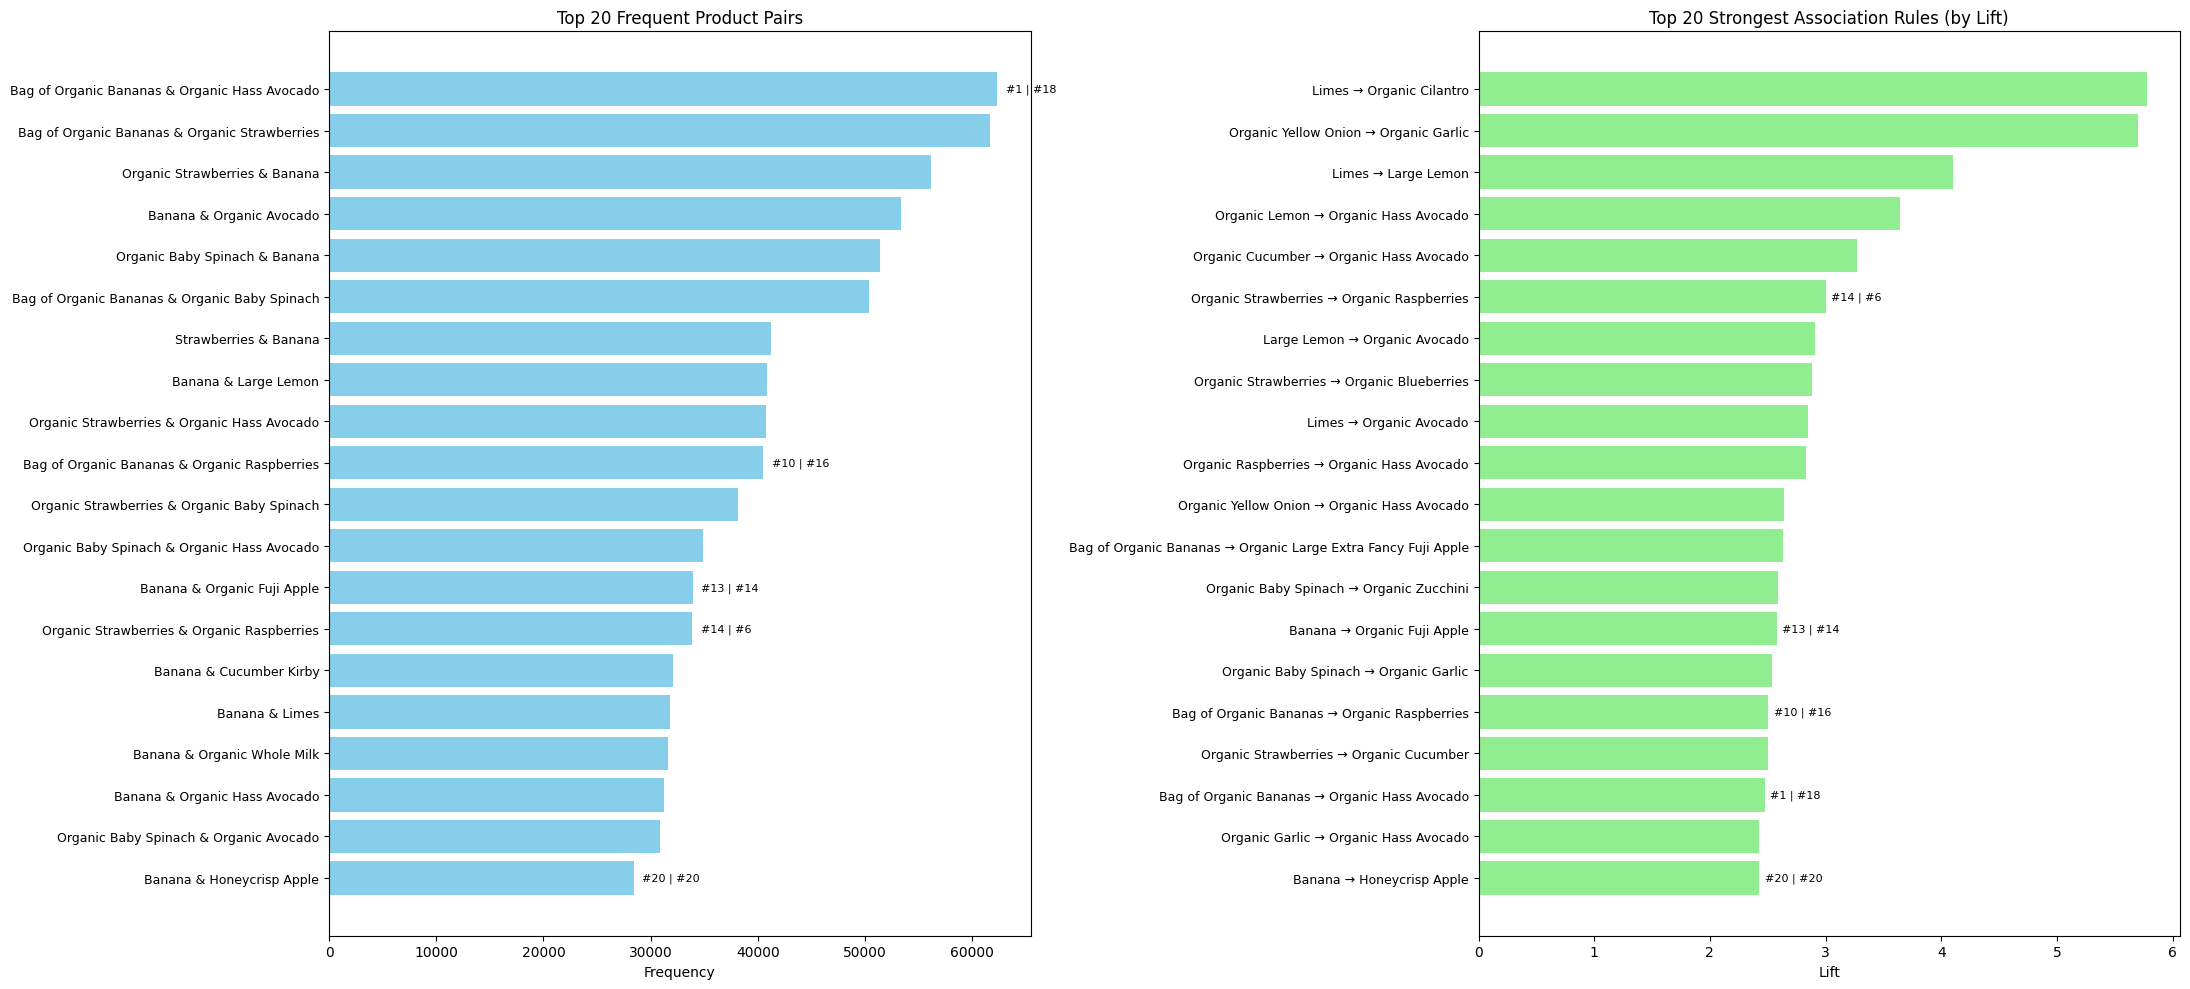

In [19]:
import matplotlib.pyplot as plt

# --- Frequent pairs (left plot) ---
top_freq_pairs = sorted(named_pairs.items(), key=lambda x: x[1], reverse=True)[:20]
freq_labels = [f"{a} & {b}" for (a, b), _ in top_freq_pairs]
freq_counts = [cnt for _, cnt in top_freq_pairs]

# --- Strongest rules by lift (right plot) ---
top_rules = df_rules.head(20)
rule_labels = [f"{row['A']} → {row['B']}" for _, row in top_rules.iterrows()]
rule_lifts = top_rules["lift"].tolist()

# --- Prepare comparable pair keys ---
freq_pairs = [tuple(sorted(label.split(" & "))) for label in freq_labels]
rule_pairs = [tuple(sorted(label.split(" → "))) for label in rule_labels]

# Rank lookup maps
freq_rank = {pair: i+1 for i, pair in enumerate(freq_pairs)}
rule_rank = {pair: i+1 for i, pair in enumerate(rule_pairs)}

# Common pairs that appear in both rankings
common_pairs = set(freq_pairs).intersection(set(rule_pairs))

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# Left plot
ax1.barh(freq_labels[::-1], freq_counts[::-1], color="skyblue")
ax1.set_title("Top 20 Frequent Product Pairs")
ax1.set_xlabel("Frequency")
ax1.tick_params(axis="y", labelsize=9)

# Add annotation "#F | #L" to left bars
for i, pair in enumerate(freq_pairs[::-1]):  
    original_index = len(freq_pairs) - 1 - i
    if pair in common_pairs:
        ax1.text(
            freq_counts[original_index] + 800,
            i,
            f"#{freq_rank[pair]} | #{rule_rank[pair]}",
            va="center",
            fontsize=8,
            color="black"
        )

# Right plot
ax2.barh(rule_labels[::-1], rule_lifts[::-1], color="lightgreen")
ax2.set_title("Top 20 Strongest Association Rules (by Lift)")
ax2.set_xlabel("Lift")
ax2.tick_params(axis="y", labelsize=9)

# Add annotation "#F | #L" to right bars
for i, pair in enumerate(rule_pairs[::-1]):
    original_index = len(rule_pairs) - 1 - i
    if pair in common_pairs:
        ax2.text(
            rule_lifts[original_index] + 0.05,
            i,
            f"#{freq_rank[pair]} | #{rule_rank[pair]}",
            va="center",
            fontsize=8,
            color="black"
        )

plt.tight_layout()
plt.show()


<h3> <span style="color: green;font-weight:bold; background-color: #f0f0f0; padding: 6px; border-radius: 4px;">
Overlap Between Frequent and Strong Association Rules </span></h3>

This table highlights product pairs that appear both among the most frequent 
co-occurring combinations and among the strongest association rules (ranked by lift).  
For each pair, its rank in the frequency-based list and in the lift-based list is shown.

In [18]:
# --- Convert labels to consistent tuple form ---
# Left plot uses "A & B"
freq_pairs = [
    tuple(sorted(label.split(" & ")))
    for label in freq_labels
]

# Right plot uses "A → B"
rule_pairs = [
    tuple(sorted(label.split(" → ")))
    for label in rule_labels
]

# --- Create lookup dictionaries for ranks ---
freq_rank = {pair: i+1 for i, pair in enumerate(freq_pairs)}   # 1-based indexing
rule_rank = {pair: i+1 for i, pair in enumerate(rule_pairs)}

# --- Compute intersection ---
common_pairs = set(freq_pairs).intersection(set(rule_pairs))

# --- Build structured results ---
rows = []
for pair in common_pairs:
    rows.append({
        "Pair": f"{pair[0]} & {pair[1]}",
        "Freq_Rank": freq_rank[pair],
        "Lift_Rank": rule_rank[pair]
    })

df_overlap = pd.DataFrame(rows).sort_values("Freq_Rank")

df_overlap.reset_index(drop=True, inplace=True)

df_overlap

,Pair,Freq_Rank,Lift_Rank
0,Bag of Organic Bananas & Organic Hass Avocado,1,18
1,Bag of Organic Bananas & Organic Raspberries,10,16
2,Banana & Organic Fuji Apple,13,14
3,Organic Raspberries & Organic Strawberries,14,6
4,Banana & Honeycrisp Apple,20,20


In [10]:
save_dir = "../../data/Georgios/pcy_pass2"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "pcy_pass2_frequent_pairs.pkl")

save_data = {
    "frequent_pairs": frequent_pairs,
    "item_counts": item_counts,
    "num_buckets": num_buckets,
    "support_threshold": support_threshold
}

with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print("Saved Pass 2 frequent pairs at:", save_path)

Saved Pass 2 frequent pairs at: ../../data/Georgios/pcy_pass2\pcy_pass2_frequent_pairs.pkl
